# Phát Hiện Bất Thường Theo Luật Nghiệp Vụ dựa trên Hành vi người dùng trong web thương mại điện tử

## RetailRocket E-Commerce Dataset

Notebook này là bản dành cho đồ án nhóm 5 người. Mục tiêu là xây dựng pipeline khai phá dữ liệu để phát hiện hành vi người dùng bất thường trong web thương mại điện tử dựa trên dữ liệu sự kiện của RetailRocket.

Dataset: https://www.kaggle.com/datasets/retailrocket/ecommerce-dataset

Đơn vị phân tích chính là `visitorid`. Dataset gốc không cung cấp nhãn bất thường thật, vì vậy nhóm tạo nhãn tham chiếu `is_anomaly_rule` từ các luật nghiệp vụ. Nhãn này được dùng để đánh giá và huấn luyện các mô hình có giám sát, không được trình bày như ground truth tuyệt đối.

## Phân công thuật toán

| Người | Thuật toán | Loại | Vai trò trong đồ án |
| --- | --- | --- | --- |
| 1 | XGBoost | Phân loại có giám sát | Mô hình boosting mạnh, xử lý tốt dữ liệu phi tuyến và mất cân bằng lớp |
| 2 | Decision Tree | Phân loại có giám sát | Mô hình dễ giải thích, có thể minh họa thành các luật quyết định |
| 3 | Random Forest | Phân loại có giám sát | Ensemble nhiều cây, ổn định hơn cây đơn và có feature importance |
| 4 | K-Means | Phân cụm không giám sát | Khám phá các nhóm hành vi và visitor xa tâm cụm |
| 5 | Isolation Forest | Phát hiện bất thường không giám sát | Thuật toán chuyên biệt cho anomaly detection |

## 1. Import và cấu hình

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

try:
    from xgboost import XGBClassifier
except Exception as exc:
    raise ImportError(
        "Chua load duoc XGBoost. Cai Python package bang `.venv/bin/python -m pip install xgboost`; "
        "tren macOS can them OpenMP runtime bang `brew install libomp`."
    ) from exc

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
OUTPUT_DIR = Path('.')
DATA_PATH = Path('./data/events.csv')

# Gioi han mau giup notebook chay on dinh va output/source khop nhau.
# Dat None neu muon train supervised models tren toan bo visitor profile.
MAX_SUPERVISED_ROWS = 250_000
KMEANS_TRAIN_ROWS = 200_000
IFOREST_TRAIN_ROWS = 250_000
PLOT_SAMPLE_ROWS = 25_000

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
COLORS = {
    'normal': '#2E7D32',
    'anomaly': '#C62828',
    'warning': '#EF6C00',
    'primary': '#1565C0',
    'secondary': '#6A1B9A',
    'dark': '#263238',
    'muted': '#607D8B',
}

print('Thu vien va cau hinh da san sang')

Thu vien va cau hinh da san sang


## 2. Tải dữ liệu và tiền xử lý chung

Dữ liệu `events.csv` gồm các hành vi của người dùng: `view`, `addtocart`, `transaction`. Phần tiền xử lý này là phần dùng chung cho cả nhóm.

In [2]:
print('Dang tai du lieu events.csv...')
events = pd.read_csv(DATA_PATH)

required_cols = {'timestamp', 'visitorid', 'event', 'itemid', 'transactionid'}
missing_cols = required_cols.difference(events.columns)
if missing_cols:
    raise ValueError(f'Thieu cot bat buoc: {sorted(missing_cols)}')

# Chuyen timestamp tu millisecond sang datetime va tao bien thoi gian.
events['datetime'] = pd.to_datetime(events['timestamp'], unit='ms')
events['date'] = events['datetime'].dt.date
events['hour'] = events['datetime'].dt.hour
events['dayofweek'] = events['datetime'].dt.dayofweek

# Sap xep theo visitor va thoi gian de tinh khoang cach giua cac su kien lien tiep.
events = events.sort_values(['visitorid', 'timestamp']).reset_index(drop=True)
events['prev_timestamp'] = events.groupby('visitorid')['timestamp'].shift(1)
events['time_diff_sec'] = (events['timestamp'] - events['prev_timestamp']) / 1000

print(f'Tong so su kien: {len(events):,}')
print(f'So visitor duy nhat: {events["visitorid"].nunique():,}')
print(f'So item duy nhat: {events["itemid"].nunique():,}')
print(f'Thoi gian: {events["datetime"].min()} -> {events["datetime"].max()}')
print('\nPhan phoi event:')
display(events['event'].value_counts().rename_axis('event').reset_index(name='count'))

Dang tai du lieu events.csv...


Tong so su kien: 2,756,101
So visitor duy nhat: 1,407,580
So item duy nhat: 235,061
Thoi gian: 2015-05-03 03:00:04.384000 -> 2015-09-18 02:59:47.788000

Phan phoi event:


,event,count
0,view,2664312
1,addtocart,69332
2,transaction,22457


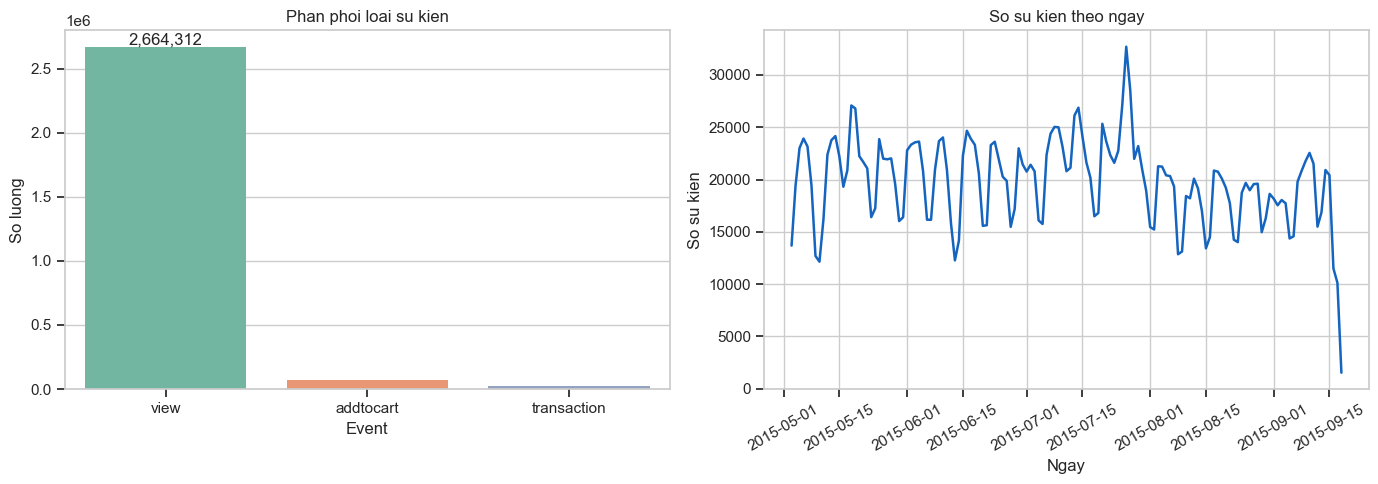

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = events['event'].value_counts().index
sns.countplot(data=events, x='event', order=order, ax=axes[0], palette='Set2')
axes[0].set_title('Phan phoi loai su kien')
axes[0].set_xlabel('Event')
axes[0].set_ylabel('So luong')
axes[0].bar_label(axes[0].containers[0], fmt='{:,.0f}')

by_day = events.groupby('date').size()
axes[1].plot(pd.to_datetime(by_day.index), by_day.values, color=COLORS['primary'], linewidth=1.8)
axes[1].set_title('So su kien theo ngay')
axes[1].set_xlabel('Ngay')
axes[1].set_ylabel('So su kien')
axes[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_event_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

## 3. Xây dựng visitor behavior profile

Mỗi dòng của bảng profile tương ứng với một `visitorid`. Đây là bảng đặc trưng dùng chung cho cả 5 thuật toán.

In [4]:
print('Dang xay dung visitor behavior profile...')
df = events.copy()

# Nhom 1: thong ke tan suat hanh vi.
total_events = df.groupby('visitorid').size().rename('total_events')
active_days = df.groupby('visitorid')['date'].nunique().rename('active_days')
unique_items = df.groupby('visitorid')['itemid'].nunique().rename('unique_items')
active_hours = df.groupby('visitorid')['hour'].nunique().rename('active_hours')
unique_event_types = df.groupby('visitorid')['event'].nunique().rename('unique_event_types')

event_counts = df.groupby(['visitorid', 'event']).size().unstack(fill_value=0)
event_counts.columns = [f'n_{col}' for col in event_counts.columns]
for col in ['n_view', 'n_addtocart', 'n_transaction']:
    if col not in event_counts.columns:
        event_counts[col] = 0

# Entropy cua event type: cao hon khi visitor co hanh vi da dang hon.
event_probs = event_counts.div(event_counts.sum(axis=1).clip(lower=1), axis=0)
event_entropy = (-(event_probs.replace(0, np.nan) * np.log2(event_probs.replace(0, np.nan))).sum(axis=1)).rename('event_type_entropy')

# Entropy theo gio trong ngay.
hour_counts = df.groupby(['visitorid', 'hour']).size().unstack(fill_value=0)
hour_probs = hour_counts.div(hour_counts.sum(axis=1).clip(lower=1), axis=0)
hour_entropy = (-(hour_probs.replace(0, np.nan) * np.log2(hour_probs.replace(0, np.nan))).sum(axis=1)).rename('hour_entropy')

# Nhom 2: toc do thao tac.
time_diffs = df.dropna(subset=['time_diff_sec'])
speed_stats = time_diffs.groupby('visitorid')['time_diff_sec'].agg(
    min_interval_sec='min',
    mean_interval_sec='mean',
    median_interval_sec='median',
    std_interval_sec='std',
)
rapid_fire_count = time_diffs[time_diffs['time_diff_sec'] < 1].groupby('visitorid').size().rename('rapid_fire_count')

# Nhom 3: thoi diem hoat dong.
night_events = df[df['hour'].between(0, 5)].groupby('visitorid').size().rename('night_events')
peak_events = df[df['hour'].between(9, 21)].groupby('visitorid').size().rename('peak_events')
weekend_events = df[df['dayofweek'].isin([5, 6])].groupby('visitorid').size().rename('weekend_events')

# Nhom 4: hanh vi tren item.
max_items_per_day = df.groupby(['visitorid', 'date'])['itemid'].nunique().groupby('visitorid').max().rename('max_items_per_day')
atc_events = df[df['event'] == 'addtocart']
if len(atc_events) > 0:
    max_same_item_atc = atc_events.groupby(['visitorid', 'itemid']).size().groupby('visitorid').max().rename('max_same_item_atc')
else:
    max_same_item_atc = pd.Series(dtype='float64', name='max_same_item_atc')

profile = pd.concat([
    total_events,
    active_days,
    unique_items,
    active_hours,
    unique_event_types,
    event_counts,
    event_entropy,
    hour_entropy,
    speed_stats,
    rapid_fire_count,
    night_events,
    peak_events,
    weekend_events,
    max_items_per_day,
    max_same_item_atc,
], axis=1).fillna(0)

profile.index.name = 'visitorid'

# Ty le va dac trung tong hop.
profile['view_rate'] = profile['n_view'] / profile['total_events'].clip(lower=1)
profile['atc_rate'] = profile['n_addtocart'] / profile['n_view'].clip(lower=1)
profile['buy_rate'] = profile['n_transaction'] / profile['n_view'].clip(lower=1)
profile['night_ratio'] = profile['night_events'] / profile['total_events'].clip(lower=1)
profile['peak_ratio'] = profile['peak_events'] / profile['total_events'].clip(lower=1)
profile['weekend_ratio'] = profile['weekend_events'] / profile['total_events'].clip(lower=1)
profile['rapid_ratio'] = profile['rapid_fire_count'] / profile['total_events'].clip(lower=1)
profile['events_per_day'] = profile['total_events'] / profile['active_days'].clip(lower=1)
profile['items_per_event'] = profile['unique_items'] / profile['total_events'].clip(lower=1)
profile['revisit_ratio'] = 1 - profile['items_per_event'].clip(upper=1)
profile['events_per_active_hour'] = profile['total_events'] / profile['active_hours'].clip(lower=1)

print(f'Profile shape: {profile.shape}')
display(profile.head())

Dang xay dung visitor behavior profile...


Profile shape: (1407580, 31)


,total_events,active_days,unique_items,active_hours,unique_event_types,n_addtocart,n_transaction,n_view,event_type_entropy,hour_entropy,...,atc_rate,buy_rate,night_ratio,peak_ratio,weekend_ratio,rapid_ratio,events_per_day,items_per_event,revisit_ratio,events_per_active_hour
visitorid,,,,,,,,,,,,,,,,,,,,,
0,3,1,3,1,1,0,0,3,-0.0,-0.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,3.0,1.0,0.0,3.0
1,1,1,1,1,1,0,0,1,-0.0,-0.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
2,8,1,4,2,1,0,0,8,-0.0,0.954434,...,0.0,0.0,0.0,1.0,0.0,0.0,8.0,0.5,0.5,4.0
3,1,1,1,1,1,0,0,1,-0.0,-0.000000,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0
4,1,1,1,1,1,0,0,1,-0.0,-0.000000,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0


In [5]:
summary_cols = [
    'total_events', 'active_days', 'unique_items', 'active_hours', 'unique_event_types',
    'n_view', 'n_addtocart', 'n_transaction', 'events_per_day', 'rapid_ratio',
    'night_ratio', 'atc_rate', 'buy_rate', 'hour_entropy', 'event_type_entropy',
]
profile_summary = profile[summary_cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T
print('Thong ke cac dac trung chinh:')
display(profile_summary)

Thong ke cac dac trung chinh:


,count,mean,std,min,50%,75%,90%,95%,99%,max
total_events,1407580.0,1.958042,12.580492,1.0,1.0,2.0,3.000000,5.0,13.000000,7757.000000
active_days,1407580.0,1.171894,0.928101,1.0,1.0,1.0,2.000000,2.0,4.000000,131.000000
unique_items,1407580.0,1.524019,7.143724,1.0,1.0,1.0,2.000000,3.0,8.000000,3814.000000
active_hours,1407580.0,1.222523,0.770179,1.0,1.0,1.0,2.000000,2.0,4.000000,24.000000
unique_event_types,1407580.0,1.032709,0.214876,1.0,1.0,1.0,1.000000,1.0,2.000000,3.000000
n_view,1407580.0,1.892832,10.993697,0.0,1.0,2.0,3.000000,5.0,12.000000,6479.000000
n_addtocart,1407580.0,0.049256,1.165057,0.0,0.0,0.0,0.000000,0.0,1.000000,719.000000
n_transaction,1407580.0,0.015954,0.826091,0.0,0.0,0.0,0.000000,0.0,0.000000,559.000000
events_per_day,1407580.0,1.508529,1.775693,1.0,1.0,1.0,2.250000,4.0,8.000000,182.000000
rapid_ratio,1407580.0,0.001405,0.022225,0.0,0.0,0.0,0.000000,0.0,0.000000,0.941176


## 4. Xây dựng luật nghiệp vụ và nhãn tham chiếu

Các luật nghiệp vụ dùng để phát hiện hành vi bất thường rõ ràng. Kết quả gộp của các luật là `is_anomaly_rule`, đóng vai trò nhãn tham chiếu cho báo cáo.

In [6]:
# Preset suspicious_behavior: tang ti le anomaly de du mau cho phan tich do an.
# Cac nguong nay gan nhan hanh vi dang nghi, khong phai ket luan gian lan chac chan.
THRESHOLDS = {
    'BR01_max_events_per_day': 20,
    'BR03_min_views_for_click_fraud': 15,
    'BR04_rapid_fire_ratio': 0.10,
    'BR04_min_events_for_rapid': 3,
    'BR05_night_ratio': 0.50,
    'BR05_min_events_for_night': 5,
    'BR06_max_same_item_atc': 2,
    'BR07_max_items_per_day': 50,
}

anomalies = profile.copy()

# BR01: Bot scraper - qua nhieu event moi ngay.
anomalies['flag_BR01_bot_scraper'] = (
    anomalies['events_per_day'] > THRESHOLDS['BR01_max_events_per_day']
).astype(int)

# BR02: Ghost buyer - co transaction nhung khong co addtocart.
anomalies['flag_BR02_ghost_buyer'] = (
    (anomalies['n_transaction'] > 0) & (anomalies['n_addtocart'] == 0)
).astype(int)

# BR03: Click fraud - view nhieu nhung khong addtocart/transaction.
anomalies['flag_BR03_click_fraud'] = (
    (anomalies['n_view'] >= THRESHOLDS['BR03_min_views_for_click_fraud'])
    & (anomalies['n_addtocart'] == 0)
    & (anomalies['n_transaction'] == 0)
).astype(int)

# BR04: Rapid fire - ty le thao tac lien tiep duoi 1 giay qua cao.
anomalies['flag_BR04_rapid_fire'] = (
    (anomalies['rapid_ratio'] > THRESHOLDS['BR04_rapid_fire_ratio'])
    & (anomalies['total_events'] > THRESHOLDS['BR04_min_events_for_rapid'])
).astype(int)

# BR05: Night crawler - phan lon hoat dong trong khung 0h-5h.
anomalies['flag_BR05_night_crawler'] = (
    (anomalies['night_ratio'] > THRESHOLDS['BR05_night_ratio'])
    & (anomalies['total_events'] >= THRESHOLDS['BR05_min_events_for_night'])
).astype(int)

# BR06: Item hoarding - them cung mot san pham vao gio qua nhieu lan.
anomalies['flag_BR06_item_hoarding'] = (
    anomalies['max_same_item_atc'] > THRESHOLDS['BR06_max_same_item_atc']
).astype(int)

# BR07: Session bomb - xem qua nhieu item khac nhau trong mot ngay.
anomalies['flag_BR07_session_bomb'] = (
    anomalies['max_items_per_day'] > THRESHOLDS['BR07_max_items_per_day']
).astype(int)

# BR08: Sequence violation - transaction cua visitor-item xuat hien truoc khi co view/addtocart truoc do.
interaction_event = df['event'].isin(['view', 'addtocart']).astype('int8')
prior_item_interactions = interaction_event.groupby([df['visitorid'], df['itemid']]).cumsum()
sequence_violators = df.loc[
    (df['event'] == 'transaction') & (prior_item_interactions == 0),
    'visitorid',
].unique()
anomalies['flag_BR08_sequence_violation'] = anomalies.index.isin(sequence_violators).astype(int)

anomaly_type_map = {
    'flag_BR01_bot_scraper': 'Bot scraper',
    'flag_BR02_ghost_buyer': 'Ghost buyer',
    'flag_BR03_click_fraud': 'Click fraud',
    'flag_BR04_rapid_fire': 'Rapid-fire',
    'flag_BR05_night_crawler': 'Night crawler',
    'flag_BR06_item_hoarding': 'Item hoarding',
    'flag_BR07_session_bomb': 'Session bomb',
    'flag_BR08_sequence_violation': 'Sequence violation',
}

flag_cols = list(anomaly_type_map.keys())
anomalies['total_flags'] = anomalies[flag_cols].sum(axis=1)
anomalies['is_anomaly_rule'] = (anomalies['total_flags'] > 0).astype(int)
anomalies['is_anomaly'] = anomalies['is_anomaly_rule']

flag_matrix = anomalies[flag_cols].to_numpy(dtype=bool)
anomaly_type_labels = np.array(list(anomaly_type_map.values()), dtype=object)
anomalies['anomaly_type_count'] = flag_matrix.sum(axis=1).astype(int)
anomalies['anomaly_types'] = [
    ', '.join(anomaly_type_labels[row_flags].tolist()) if row_flags.any() else 'Normal'
    for row_flags in flag_matrix
]

if not (anomalies['anomaly_type_count'] == anomalies['total_flags']).all():
    raise ValueError('anomaly_type_count phai bang total_flags')
if not (anomalies.loc[anomalies['is_anomaly'] == 0, 'anomaly_types'] == 'Normal').all():
    raise ValueError('Visitor binh thuong phai co anomaly_types = Normal')

rule_summary = (
    anomalies[flag_cols]
    .sum()
    .rename('count')
    .reset_index()
    .rename(columns={'index': 'flag'})
)
rule_summary['anomaly_type'] = rule_summary['flag'].map(anomaly_type_map)
rule_summary['percent_visitors'] = rule_summary['count'] / len(anomalies) * 100
rule_summary = rule_summary[['flag', 'anomaly_type', 'count', 'percent_visitors']].sort_values('count', ascending=False)
anomaly_type_breakdown = rule_summary[['anomaly_type', 'count', 'percent_visitors']].copy()

visitor_anomaly_tags = anomalies[
    ['is_anomaly', 'anomaly_types', 'anomaly_type_count', 'total_flags'] + flag_cols
].reset_index()

print('Nguong luat nghiep vu:')
for key, value in THRESHOLDS.items():
    print(f'- {key}: {value}')

print(f'\nSo visitor bat thuong theo luat: {anomalies["is_anomaly_rule"].sum():,} / {len(anomalies):,} '
      f'({anomalies["is_anomaly_rule"].mean() * 100:.2f}%)')
print(f'So visitor vi pham Sequence violation: {anomalies["flag_BR08_sequence_violation"].sum():,}')
display(rule_summary)
print('\nVi du multi-label anomaly tagging:')
display(visitor_anomaly_tags[visitor_anomaly_tags['is_anomaly'] == 1].head(10))

Nguong luat nghiep vu:
- BR01_max_events_per_day: 20
- BR03_min_views_for_click_fraud: 15
- BR04_rapid_fire_ratio: 0.1
- BR04_min_events_for_rapid: 3
- BR05_night_ratio: 0.5
- BR05_min_events_for_night: 5
- BR06_max_same_item_atc: 2
- BR07_max_items_per_day: 50

So visitor bat thuong theo luat: 33,421 / 1,407,580 (2.37%)
So visitor vi pham Sequence violation: 444


,flag,anomaly_type,count,percent_visitors
4,flag_BR05_night_crawler,Night crawler,24265,1.723881
2,flag_BR03_click_fraud,Click fraud,6452,0.458375
3,flag_BR04_rapid_fire,Rapid-fire,3711,0.263644
0,flag_BR01_bot_scraper,Bot scraper,1275,0.090581
1,flag_BR02_ghost_buyer,Ghost buyer,1143,0.081203
5,flag_BR06_item_hoarding,Item hoarding,735,0.052217
7,flag_BR08_sequence_violation,Sequence violation,444,0.031544
6,flag_BR07_session_bomb,Session bomb,188,0.013356



Vi du multi-label anomaly tagging:


,visitorid,is_anomaly,anomaly_types,anomaly_type_count,total_flags,flag_BR01_bot_scraper,flag_BR02_ghost_buyer,flag_BR03_click_fraud,flag_BR04_rapid_fire,flag_BR05_night_crawler,flag_BR06_item_hoarding,flag_BR07_session_bomb,flag_BR08_sequence_violation
75,75,1,Click fraud,1,1,0,0,1,0,0,0,0,0
97,97,1,Night crawler,1,1,0,0,0,0,1,0,0,0
162,162,1,Night crawler,1,1,0,0,0,0,1,0,0,0
172,172,1,Night crawler,1,1,0,0,0,0,1,0,0,0
224,224,1,Night crawler,1,1,0,0,0,0,1,0,0,0
264,264,1,Rapid-fire,1,1,0,0,0,1,0,0,0,0
344,344,1,Night crawler,1,1,0,0,0,0,1,0,0,0
351,351,1,Click fraud,1,1,0,0,1,0,0,0,0,0
374,374,1,Night crawler,1,1,0,0,0,0,1,0,0,0
387,387,1,Night crawler,1,1,0,0,0,0,1,0,0,0


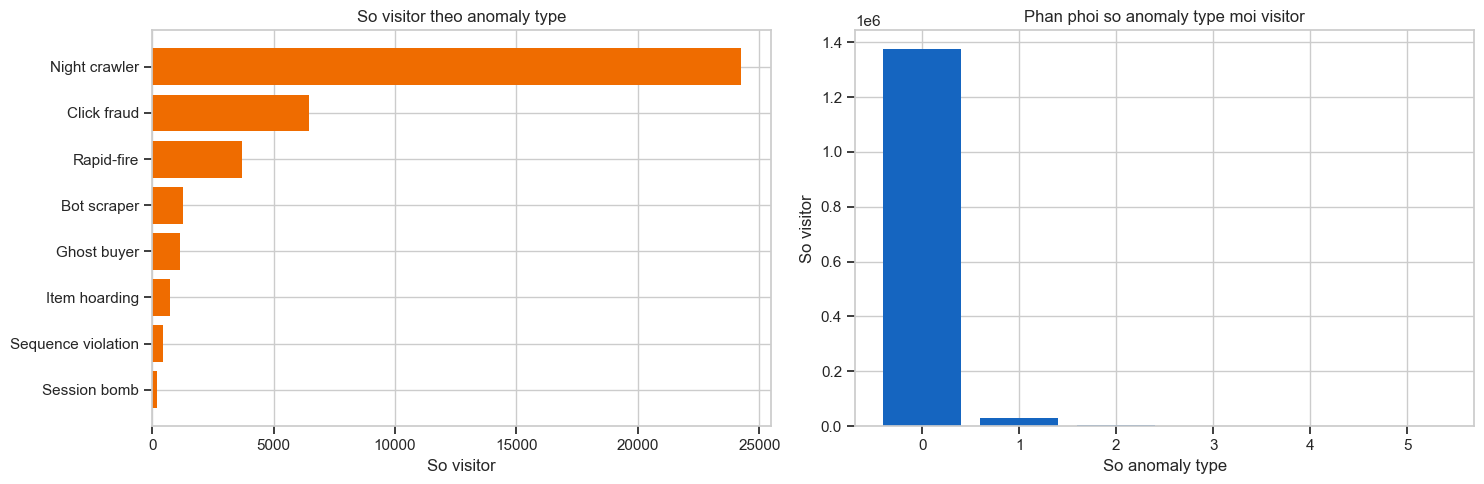

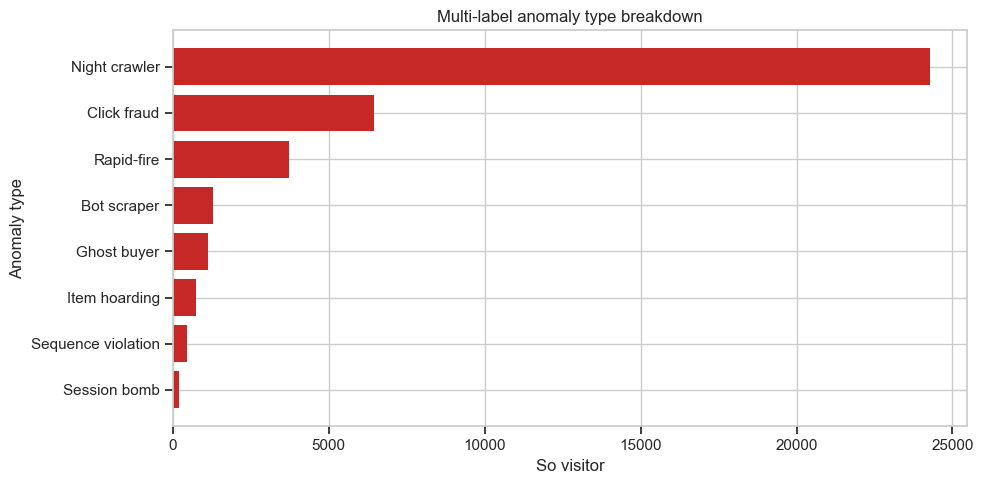

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_rules = rule_summary.sort_values('count', ascending=True)
axes[0].barh(plot_rules['anomaly_type'], plot_rules['count'], color=COLORS['warning'])
axes[0].set_title('So visitor theo anomaly type')
axes[0].set_xlabel('So visitor')

flag_distribution = anomalies['total_flags'].value_counts().sort_index()
axes[1].bar(flag_distribution.index.astype(str), flag_distribution.values, color=COLORS['primary'])
axes[1].set_title('Phan phoi so anomaly type moi visitor')
axes[1].set_xlabel('So anomaly type')
axes[1].set_ylabel('So visitor')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_rule_breakdown.png', dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
plot_type_breakdown = anomaly_type_breakdown.sort_values('count', ascending=True)
ax.barh(plot_type_breakdown['anomaly_type'], plot_type_breakdown['count'], color=COLORS['anomaly'])
ax.set_title('Multi-label anomaly type breakdown')
ax.set_xlabel('So visitor')
ax.set_ylabel('Anomaly type')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_anomaly_type_breakdown.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Kiểm tra rò rỉ nhãn theo luật nghiệp vụ

Nếu mô hình có giám sát được train bằng đúng các feature tạo ra `is_anomaly_rule`, metric sẽ rất đẹp vì mô hình đang học lại công thức tạo nhãn. Phần này tách feature thành hai nhóm để báo cáo trung thực hơn.

Audit rò rỉ nhãn: full feature set chứa các feature tạo luật, safe feature set đã loại các feature đó.


,rule,business_condition,rule_input_features,leaked_inputs_in_full_features,inputs_remaining_in_safe_features,n_leaked_inputs
0,BR01_bot_scraper,events_per_day > 100,"[events_per_day, total_events, active_days]","[events_per_day, total_events, active_days]",[],3
1,BR02_ghost_buyer,n_transaction > 0 and n_addtocart == 0,"[n_transaction, n_addtocart]","[n_transaction, n_addtocart]",[],2
2,BR03_click_fraud,n_view >= 50 and n_addtocart == 0 and n_transa...,"[n_view, n_addtocart, n_transaction]","[n_view, n_addtocart, n_transaction]",[],3
3,BR04_rapid_fire,rapid_ratio > 0.30 and total_events > 5,"[rapid_ratio, rapid_fire_count, total_events]","[rapid_ratio, rapid_fire_count, total_events]",[],3
4,BR05_night_crawler,night_ratio > 0.80 and total_events >= 10,"[night_ratio, night_events, total_events]","[night_ratio, night_events, total_events]",[],3
5,BR06_item_hoarding,max_same_item_atc > 5,[max_same_item_atc],[max_same_item_atc],[],1
6,BR07_session_bomb,max_items_per_day > 200,[max_items_per_day],[max_items_per_day],[],1
7,BR08_sequence_violation,transaction before prior view/addtocart on sam...,[raw_event_sequence],[],[],0


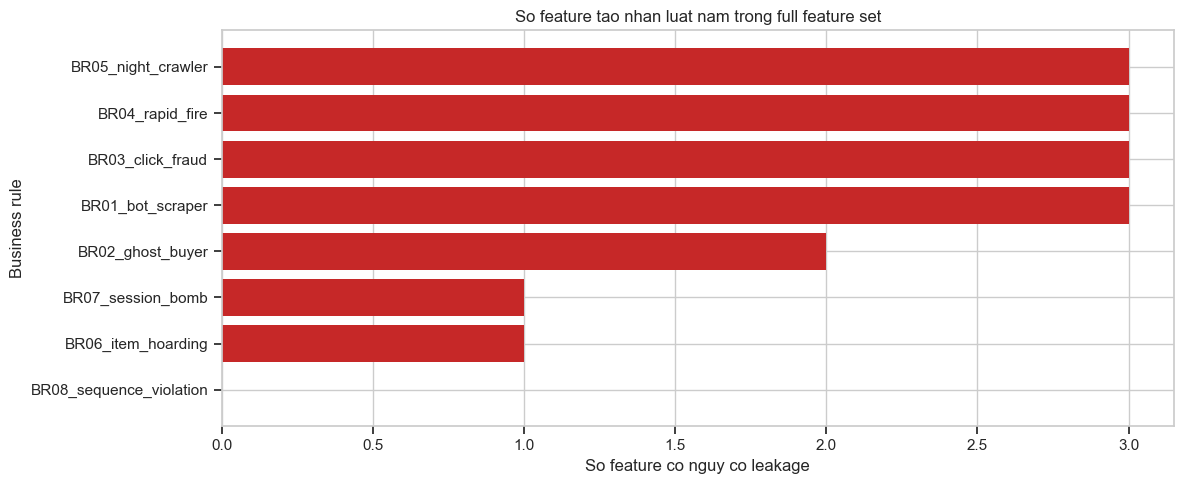

In [8]:
leakage_audit_df = pd.DataFrame([
    {
        'rule': 'BR01_bot_scraper',
        'business_condition': 'events_per_day > 100',
        'rule_input_features': ['events_per_day', 'total_events', 'active_days'],
    },
    {
        'rule': 'BR02_ghost_buyer',
        'business_condition': 'n_transaction > 0 and n_addtocart == 0',
        'rule_input_features': ['n_transaction', 'n_addtocart'],
    },
    {
        'rule': 'BR03_click_fraud',
        'business_condition': 'n_view >= 50 and n_addtocart == 0 and n_transaction == 0',
        'rule_input_features': ['n_view', 'n_addtocart', 'n_transaction'],
    },
    {
        'rule': 'BR04_rapid_fire',
        'business_condition': 'rapid_ratio > 0.30 and total_events > 5',
        'rule_input_features': ['rapid_ratio', 'rapid_fire_count', 'total_events'],
    },
    {
        'rule': 'BR05_night_crawler',
        'business_condition': 'night_ratio > 0.80 and total_events >= 10',
        'rule_input_features': ['night_ratio', 'night_events', 'total_events'],
    },
    {
        'rule': 'BR06_item_hoarding',
        'business_condition': 'max_same_item_atc > 5',
        'rule_input_features': ['max_same_item_atc'],
    },
    {
        'rule': 'BR07_session_bomb',
        'business_condition': 'max_items_per_day > 200',
        'rule_input_features': ['max_items_per_day'],
    },
    {
        'rule': 'BR08_sequence_violation',
        'business_condition': 'transaction before prior view/addtocart on same visitor-item timeline',
        'rule_input_features': ['raw_event_sequence'],
    },
])

full_feature_cols = [
    'total_events', 'active_days', 'unique_items', 'active_hours', 'unique_event_types',
    'n_view', 'n_addtocart', 'n_transaction',
    'event_type_entropy', 'hour_entropy',
    'min_interval_sec', 'mean_interval_sec', 'median_interval_sec', 'std_interval_sec',
    'rapid_fire_count', 'night_events', 'peak_events', 'weekend_events',
    'view_rate', 'atc_rate', 'buy_rate',
    'night_ratio', 'peak_ratio', 'weekend_ratio', 'rapid_ratio',
    'events_per_day', 'items_per_event', 'revisit_ratio', 'events_per_active_hour',
    'max_items_per_day', 'max_same_item_atc',
]

# Safe feature set: loai bo feature truc tiep tao nhan va cac bien dan xuat qua gan voi rule.
safe_feature_cols = [
    'unique_items',
    'active_hours',
    'unique_event_types',
    'event_type_entropy',
    'hour_entropy',
    'min_interval_sec',
    'mean_interval_sec',
    'median_interval_sec',
    'std_interval_sec',
    'peak_events',
    'weekend_events',
    'peak_ratio',
    'weekend_ratio',
]

leaky_feature_set = set(full_feature_cols).difference(safe_feature_cols)
leakage_audit_df['leaked_inputs_in_full_features'] = leakage_audit_df['rule_input_features'].apply(
    lambda cols: [col for col in cols if col in leaky_feature_set]
)
leakage_audit_df['inputs_remaining_in_safe_features'] = leakage_audit_df['rule_input_features'].apply(
    lambda cols: [col for col in cols if col in safe_feature_cols]
)
leakage_audit_df['n_leaked_inputs'] = leakage_audit_df['leaked_inputs_in_full_features'].str.len()

print('Audit rò rỉ nhãn: full feature set chứa các feature tạo luật, safe feature set đã loại các feature đó.')
display(leakage_audit_df)

if leakage_audit_df['inputs_remaining_in_safe_features'].str.len().sum() != 0:
    raise ValueError('safe_feature_cols van chua feature truc tiep tao nhan luat')

fig, ax = plt.subplots(figsize=(12, 5))
plot_leakage = leakage_audit_df.sort_values('n_leaked_inputs', ascending=True)
ax.barh(plot_leakage['rule'], plot_leakage['n_leaked_inputs'], color=COLORS['anomaly'])
ax.set_title('So feature tao nhan luat nam trong full feature set')
ax.set_xlabel('So feature co nguy co leakage')
ax.set_ylabel('Business rule')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_leakage_audit.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Chuẩn bị dữ liệu mô hình

Bảng metric chính dùng `safe_feature_cols`. Bảng phụ `full_feature_cols` chỉ dùng để minh họa khả năng mô hình học lại luật nghiệp vụ, không dùng làm kết luận chính.

In [9]:
def make_clean_matrix(source_df, columns):
    X_matrix = source_df[columns].replace([np.inf, -np.inf], np.nan).fillna(0).astype('float32')
    if X_matrix.isna().any().any():
        raise ValueError('X van con NaN sau tien xu ly')
    if not np.isfinite(X_matrix.to_numpy()).all():
        raise ValueError('X van con inf sau tien xu ly')
    return X_matrix

X_full = make_clean_matrix(anomalies, full_feature_cols)
X_safe = make_clean_matrix(anomalies, safe_feature_cols)
y = anomalies['is_anomaly_rule'].astype(int)

if y.nunique() != 2:
    raise ValueError('Nhãn is_anomaly_rule phai co du 2 lop')

safe_scaler = RobustScaler()
X_safe_scaled = safe_scaler.fit_transform(X_safe).astype('float32')

full_scaler = RobustScaler()
X_full_scaled = full_scaler.fit_transform(X_full).astype('float32')

all_indices = np.arange(len(y))
if MAX_SUPERVISED_ROWS is not None and len(y) > MAX_SUPERVISED_ROWS:
    supervised_indices, _ = train_test_split(
        all_indices,
        train_size=MAX_SUPERVISED_ROWS,
        random_state=RANDOM_STATE,
        stratify=y,
    )
else:
    supervised_indices = all_indices

train_idx, test_idx = train_test_split(
    supervised_indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y.iloc[supervised_indices],
)

X_safe_train = X_safe.iloc[train_idx]
X_safe_test = X_safe.iloc[test_idx]
X_full_train = X_full.iloc[train_idx]
X_full_test = X_full.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print(f'Toan bo visitor profile: {len(X_safe):,} dong')
print(f'Mau supervised training/evaluation: {len(supervised_indices):,} dong')
print(f'Train: {len(train_idx):,}; Test: {len(test_idx):,}')
print(f'Ty le anomaly trong toan bo profile: {y.mean() * 100:.2f}%')
print(f'Ty le anomaly trong mau supervised: {y.iloc[supervised_indices].mean() * 100:.2f}%')
print(f'So safe features: {len(safe_feature_cols)}; So full features: {len(full_feature_cols)}')

Toan bo visitor profile: 1,407,580 dong
Mau supervised training/evaluation: 250,000 dong
Train: 200,000; Test: 50,000
Ty le anomaly trong toan bo profile: 2.37%
Ty le anomaly trong mau supervised: 2.37%
So safe features: 13; So full features: 31


In [10]:
evaluation_records = []
prediction_sets = {}
main_model_predictions = {}


def add_evaluation(model_name, feature_set, evaluation_type, y_true, y_pred, y_score=None, store_confusion=True):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    record = {
        'model': model_name,
        'feature_set': feature_set,
        'evaluation_type': evaluation_type,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': np.nan,
        'pr_auc': np.nan,
        'support_anomaly': int(y_true.sum()),
        'predicted_anomaly': int(y_pred.sum()),
    }

    if y_score is not None and len(np.unique(y_true)) == 2:
        try:
            record['roc_auc'] = roc_auc_score(y_true, y_score)
        except ValueError:
            record['roc_auc'] = np.nan
        try:
            record['pr_auc'] = average_precision_score(y_true, y_score)
        except ValueError:
            record['pr_auc'] = np.nan

    evaluation_records.append(record)
    key = f'{model_name} ({feature_set})'
    if store_confusion:
        prediction_sets[key] = {
            'y_true': y_true,
            'y_pred': y_pred,
            'evaluation_type': evaluation_type,
        }

    print(f'\n{model_name} - {feature_set} - {evaluation_type}')
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly'], zero_division=0))

## 7. Baseline và mô hình supervised trên safe feature set

Đây là bảng metric chính cho các mô hình có giám sát. Vì vẫn dùng pseudo-label từ luật nghiệp vụ, kết quả chỉ thể hiện mức độ khớp với luật trên bộ feature đã giảm leakage.

In [11]:
dummy_model = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy_model.fit(X_safe_train, y_train)
dummy_test_pred = dummy_model.predict(X_safe_test)
dummy_test_score = dummy_model.predict_proba(X_safe_test)[:, 1]
add_evaluation(
    'Dummy baseline',
    'safe_features',
    'Baseline vs pseudo-label',
    y_test,
    dummy_test_pred,
    dummy_test_score,
    store_confusion=False,
)


Dummy baseline - safe_features - Baseline vs pseudo-label
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98     48813
     Anomaly       0.02      0.02      0.02      1187

    accuracy                           0.95     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.95      0.95      0.95     50000



### Người 1 - XGBoost

In [12]:
def make_xgb_model(n_estimators=120, scale_pos_weight=1.0):
    return XGBClassifier(
        n_estimators=n_estimators,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.85,
        colsample_bytree=0.85,
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
    )

neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
scale_pos_weight = neg_count / max(pos_count, 1)

xgb_safe_model = make_xgb_model(n_estimators=120, scale_pos_weight=scale_pos_weight)
xgb_safe_model.fit(X_safe_train, y_train)
xgb_safe_score = xgb_safe_model.predict_proba(X_safe_test)[:, 1]
xgb_safe_pred = (xgb_safe_score >= 0.5).astype(int)
add_evaluation('XGBoost', 'safe_features', 'Main supervised vs pseudo-label', y_test, xgb_safe_pred, xgb_safe_score)

anomalies['xgboost_score'] = xgb_safe_model.predict_proba(X_safe)[:, 1]
anomalies['xgboost_pred'] = (anomalies['xgboost_score'] >= 0.5).astype(int)
main_model_predictions['xgboost_pred'] = anomalies['xgboost_pred']


XGBoost - safe_features - Main supervised vs pseudo-label
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98     48813
     Anomaly       0.39      0.99      0.56      1187

    accuracy                           0.96     50000
   macro avg       0.69      0.98      0.77     50000
weighted avg       0.99      0.96      0.97     50000



### Người 2 - Decision Tree


Decision Tree - safe_features - Main supervised vs pseudo-label
              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97     48813
     Anomaly       0.27      0.99      0.43      1187

    accuracy                           0.94     50000
   macro avg       0.64      0.97      0.70     50000
weighted avg       0.98      0.94      0.95     50000



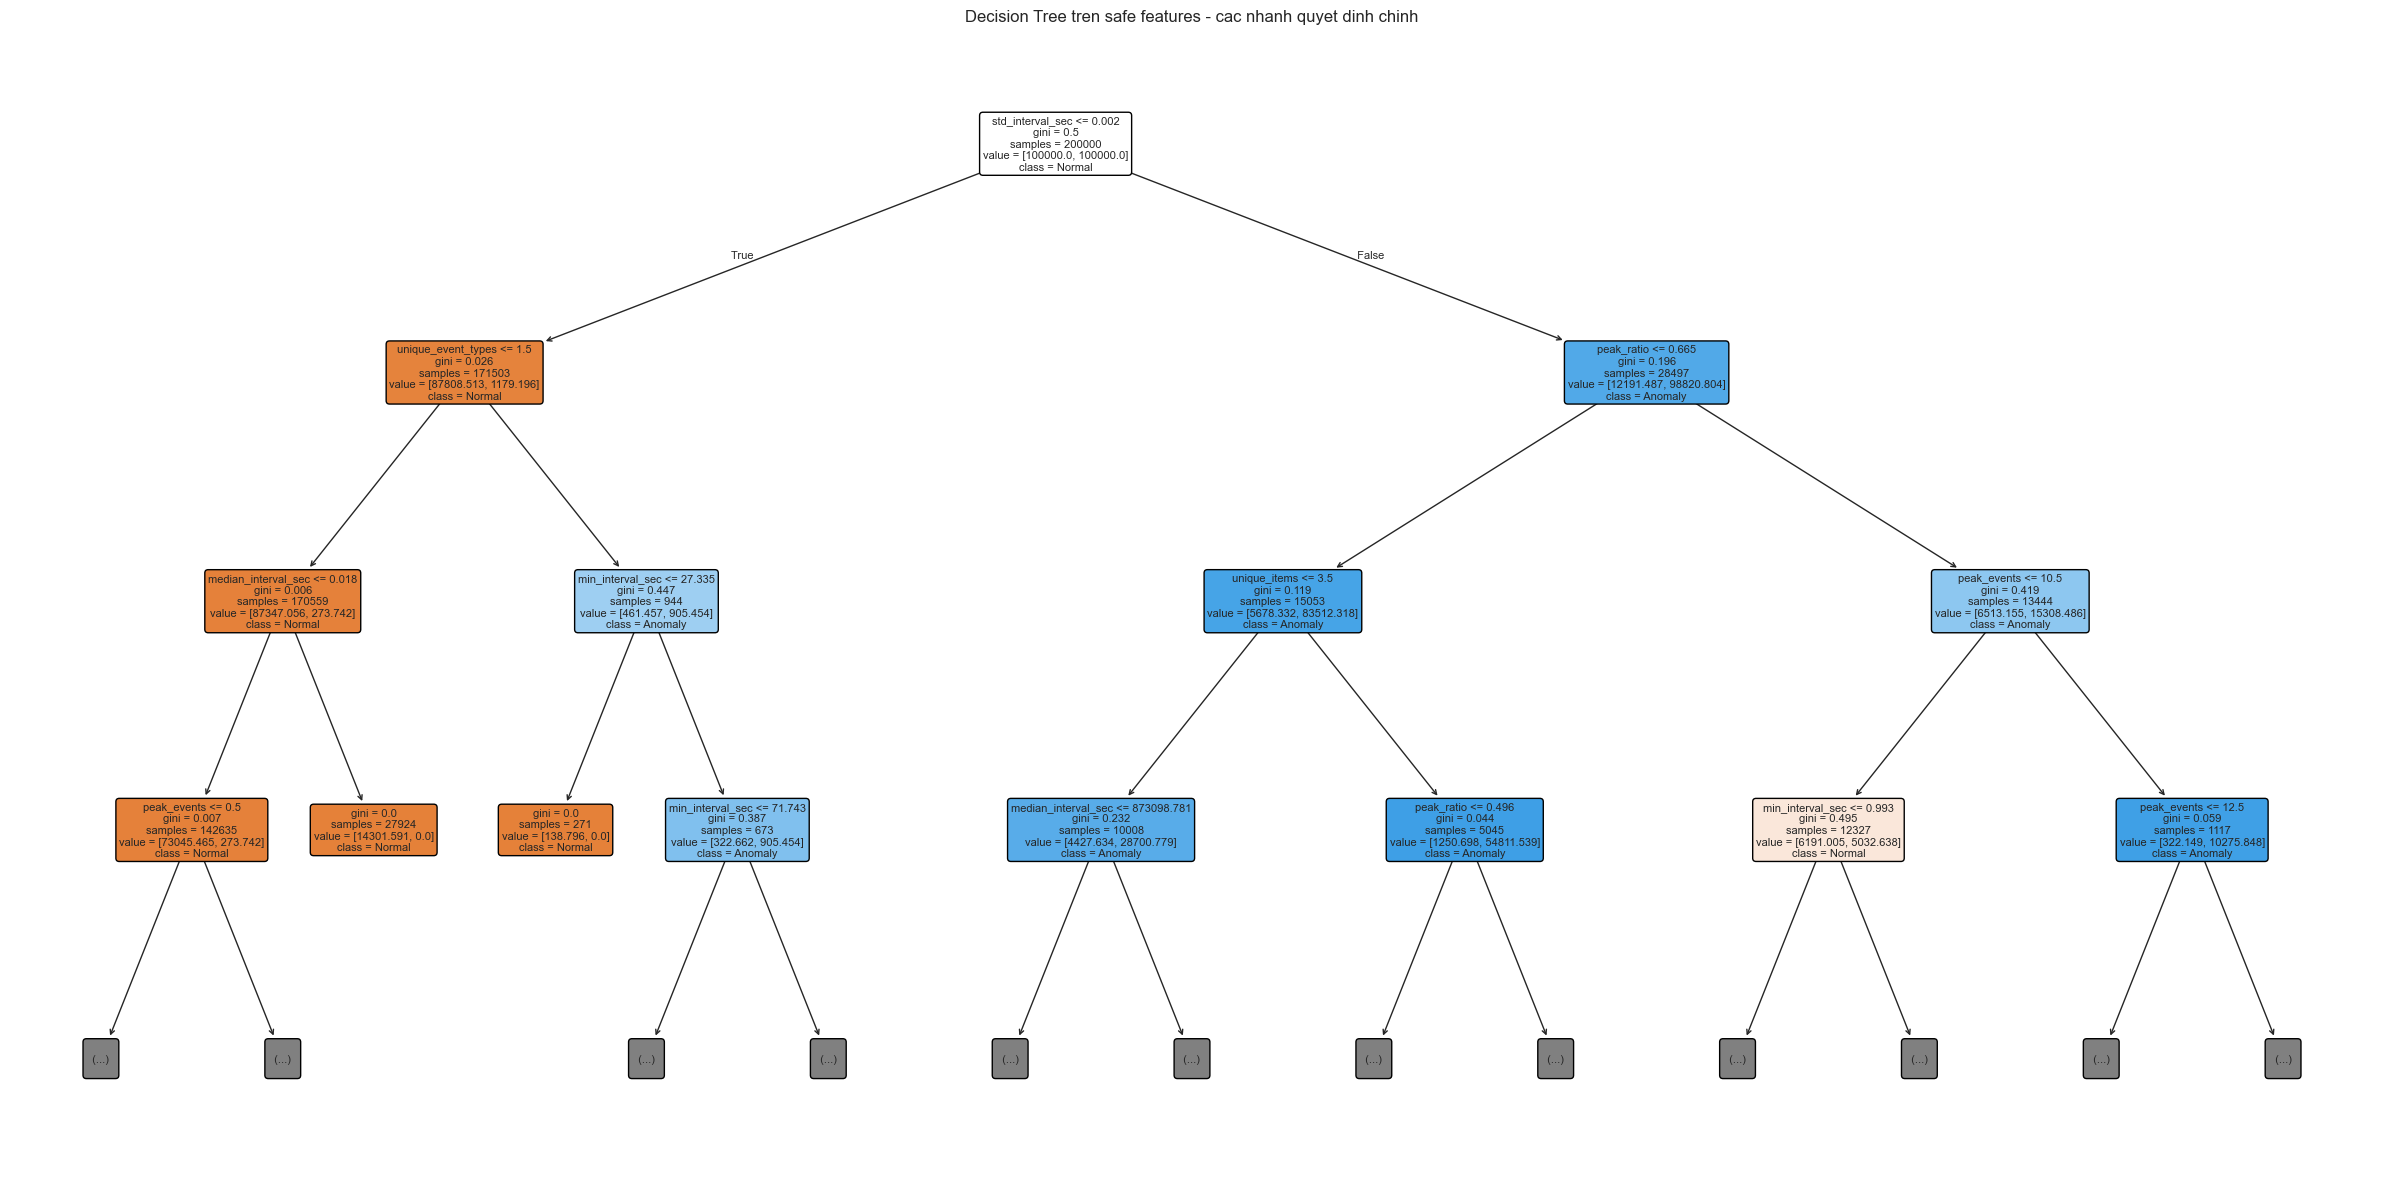

In [13]:
dt_safe_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)

dt_safe_model.fit(X_safe_train, y_train)
dt_safe_score = dt_safe_model.predict_proba(X_safe_test)[:, 1]
dt_safe_pred = (dt_safe_score >= 0.5).astype(int)
add_evaluation('Decision Tree', 'safe_features', 'Main supervised vs pseudo-label', y_test, dt_safe_pred, dt_safe_score)

anomalies['decision_tree_score'] = dt_safe_model.predict_proba(X_safe)[:, 1]
anomalies['decision_tree_pred'] = (anomalies['decision_tree_score'] >= 0.5).astype(int)
main_model_predictions['decision_tree_pred'] = anomalies['decision_tree_pred']

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    dt_safe_model,
    feature_names=safe_feature_cols,
    class_names=['Normal', 'Anomaly'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    ax=ax,
)
ax.set_title('Decision Tree tren safe features - cac nhanh quyet dinh chinh')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_decision_tree.png', dpi=160, bbox_inches='tight')
plt.show()

### Người 3 - Random Forest

In [14]:
rf_safe_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    min_samples_leaf=50,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_safe_model.fit(X_safe_train, y_train)
rf_safe_score = rf_safe_model.predict_proba(X_safe_test)[:, 1]
rf_safe_pred = (rf_safe_score >= 0.5).astype(int)
add_evaluation('Random Forest', 'safe_features', 'Main supervised vs pseudo-label', y_test, rf_safe_pred, rf_safe_score)

anomalies['random_forest_score'] = rf_safe_model.predict_proba(X_safe)[:, 1]
anomalies['random_forest_pred'] = (anomalies['random_forest_score'] >= 0.5).astype(int)
main_model_predictions['random_forest_pred'] = anomalies['random_forest_pred']


Random Forest - safe_features - Main supervised vs pseudo-label
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     48813
     Anomaly       0.33      0.99      0.50      1187

    accuracy                           0.95     50000
   macro avg       0.66      0.97      0.74     50000
weighted avg       0.98      0.95      0.96     50000



## 8. Bảng phụ: mô hình học lại luật bằng full feature set

Phần này chủ động giữ các feature tạo luật để cho thấy vì sao metric ban đầu quá đẹp. Không dùng bảng này làm kết luận chính.

In [15]:
xgb_full_model = make_xgb_model(n_estimators=120, scale_pos_weight=scale_pos_weight)
xgb_full_model.fit(X_full_train, y_train)
xgb_full_score = xgb_full_model.predict_proba(X_full_test)[:, 1]
xgb_full_pred = (xgb_full_score >= 0.5).astype(int)
add_evaluation('XGBoost', 'full_features', 'Rule-mimic / agreement with business rules', y_test, xgb_full_pred, xgb_full_score, store_confusion=False)

dt_full_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)
dt_full_model.fit(X_full_train, y_train)
dt_full_score = dt_full_model.predict_proba(X_full_test)[:, 1]
dt_full_pred = (dt_full_score >= 0.5).astype(int)
add_evaluation('Decision Tree', 'full_features', 'Rule-mimic / agreement with business rules', y_test, dt_full_pred, dt_full_score, store_confusion=False)

rf_full_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    min_samples_leaf=50,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_full_model.fit(X_full_train, y_train)
rf_full_score = rf_full_model.predict_proba(X_full_test)[:, 1]
rf_full_pred = (rf_full_score >= 0.5).astype(int)
add_evaluation('Random Forest', 'full_features', 'Rule-mimic / agreement with business rules', y_test, rf_full_pred, rf_full_score, store_confusion=False)


XGBoost - full_features - Rule-mimic / agreement with business rules
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     48813
     Anomaly       0.97      1.00      0.98      1187

    accuracy                           1.00     50000
   macro avg       0.99      1.00      0.99     50000
weighted avg       1.00      1.00      1.00     50000




Decision Tree - full_features - Rule-mimic / agreement with business rules
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     48813
     Anomaly       0.83      1.00      0.90      1187

    accuracy                           0.99     50000
   macro avg       0.91      1.00      0.95     50000
weighted avg       1.00      0.99      1.00     50000




Random Forest - full_features - Rule-mimic / agreement with business rules
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     48813
     Anomaly       0.80      1.00      0.89      1187

    accuracy                           0.99     50000
   macro avg       0.90      1.00      0.94     50000
weighted avg       1.00      0.99      0.99     50000



## 9. Shuffle-label sanity check

Nếu tráo nhãn mà mô hình vẫn đạt metric rất cao, pipeline còn rò rỉ hoặc cách đánh giá sai. Kết quả mong đợi là PR-AUC gần với tỉ lệ anomaly.

In [16]:
rng = np.random.default_rng(RANDOM_STATE)
y_train_shuffled = pd.Series(rng.permutation(y_train.to_numpy()), index=y_train.index)
shuffle_pos = int((y_train_shuffled == 1).sum())
shuffle_neg = int((y_train_shuffled == 0).sum())
shuffle_scale_pos_weight = shuffle_neg / max(shuffle_pos, 1)

xgb_shuffle_model = make_xgb_model(n_estimators=60, scale_pos_weight=shuffle_scale_pos_weight)
xgb_shuffle_model.fit(X_safe_train, y_train_shuffled)
shuffle_score = xgb_shuffle_model.predict_proba(X_safe_test)[:, 1]
shuffle_pred = (shuffle_score >= 0.5).astype(int)
add_evaluation(
    'XGBoost shuffled-label sanity check',
    'safe_features',
    'Sanity check: shuffled labels should fail',
    y_test,
    shuffle_pred,
    shuffle_score,
    store_confusion=False,
)

shuffle_pr_auc = average_precision_score(y_test, shuffle_score)
print(f'PR-AUC shuffled-label: {shuffle_pr_auc:.4f}; prevalence anomaly test: {y_test.mean():.4f}')
if shuffle_pr_auc > max(0.20, y_test.mean() * 10):
    print('Canh bao: shuffle-label PR-AUC cao bat thuong, can audit lai pipeline.')
else:
    print('Sanity check dat: model khong con dep khi nhan bi trao ngau nhien.')


XGBoost shuffled-label sanity check - safe_features - Sanity check: shuffled labels should fail
              precision    recall  f1-score   support

      Normal       0.97      0.51      0.67     48813
     Anomaly       0.01      0.28      0.03      1187

    accuracy                           0.50     50000
   macro avg       0.49      0.39      0.35     50000
weighted avg       0.94      0.50      0.65     50000

PR-AUC shuffled-label: 0.0508; prevalence anomaly test: 0.0237
Sanity check dat: model khong con dep khi nhan bi trao ngau nhien.


## 10. Feature importance trên safe feature set

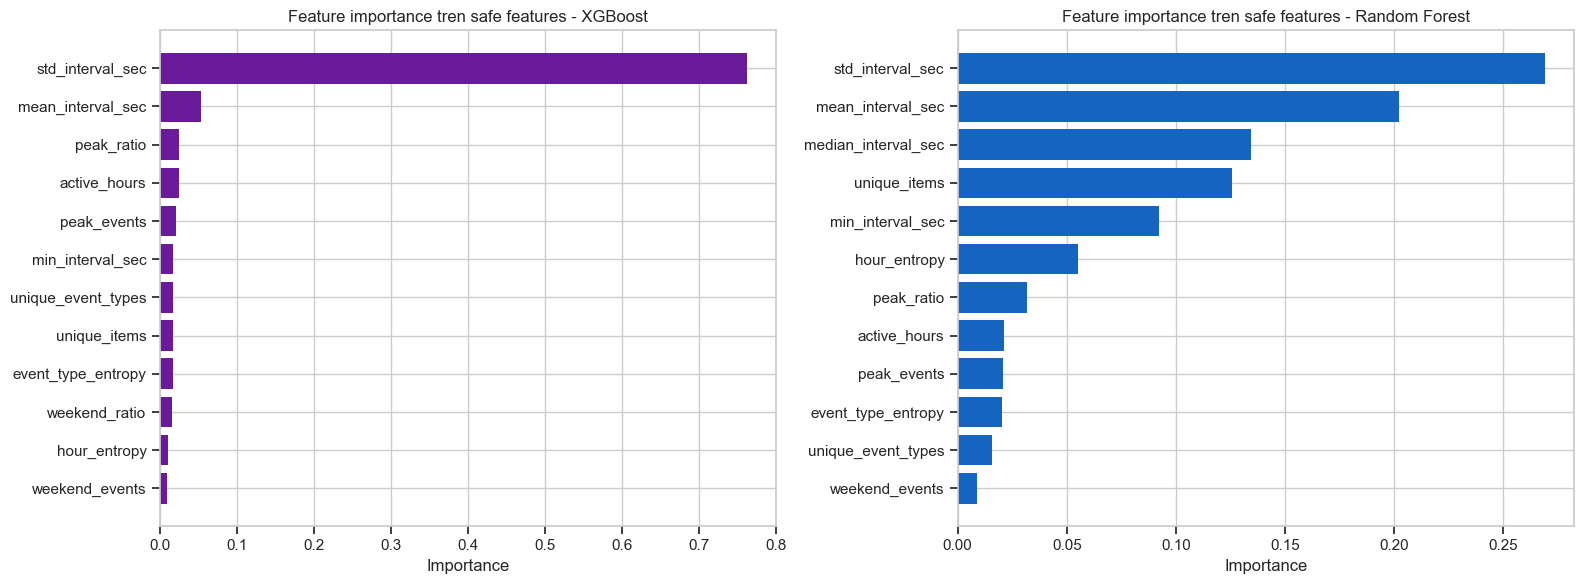

,feature,importance,model
0,std_interval_sec,0.762387,XGBoost
1,mean_interval_sec,0.053722,XGBoost
2,peak_ratio,0.025561,XGBoost
3,active_hours,0.025163,XGBoost
4,peak_events,0.020467,XGBoost
5,min_interval_sec,0.017040,XGBoost
6,unique_event_types,0.016959,XGBoost
7,unique_items,0.016871,XGBoost
8,event_type_entropy,0.016823,XGBoost
9,weekend_ratio,0.016239,XGBoost


In [17]:
def top_importance_frame(model, feature_names, name, top_n=12):
    frame = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_,
        'model': name,
    })
    return frame.sort_values('importance', ascending=False).head(top_n)

importance_df = pd.concat([
    top_importance_frame(xgb_safe_model, safe_feature_cols, 'XGBoost'),
    top_importance_frame(rf_safe_model, safe_feature_cols, 'Random Forest'),
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model_name in zip(axes, ['XGBoost', 'Random Forest']):
    subset = importance_df[importance_df['model'] == model_name].sort_values('importance', ascending=True)
    ax.barh(subset['feature'], subset['importance'], color=COLORS['secondary'] if model_name == 'XGBoost' else COLORS['primary'])
    ax.set_title(f'Feature importance tren safe features - {model_name}')
    ax.set_xlabel('Importance')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()

display(importance_df)

## 11. Người 4 - K-Means

K-Means là thuật toán phân cụm không giám sát. Mô hình không học từ nhãn `is_anomaly_rule`; nhãn luật chỉ được dùng sau đó để đo mức độ trùng khớp tham khảo.

In [18]:
if KMEANS_TRAIN_ROWS is not None and len(X_safe_scaled) > KMEANS_TRAIN_ROWS:
    rng = np.random.default_rng(RANDOM_STATE)
    kmeans_train_indices = rng.choice(len(X_safe_scaled), size=KMEANS_TRAIN_ROWS, replace=False)
else:
    kmeans_train_indices = np.arange(len(X_safe_scaled))

kmeans_model = KMeans(
    n_clusters=5,
    n_init=10,
    max_iter=100,
    random_state=RANDOM_STATE,
)
kmeans_model.fit(X_safe_scaled[kmeans_train_indices])

kmeans_cluster = kmeans_model.predict(X_safe_scaled)
kmeans_distance = kmeans_model.transform(X_safe_scaled).min(axis=1)
kmeans_threshold = np.quantile(kmeans_distance, 0.95)
kmeans_pred = (kmeans_distance >= kmeans_threshold).astype(int)

anomalies['kmeans_cluster'] = kmeans_cluster
anomalies['kmeans_distance'] = kmeans_distance
anomalies['kmeans_pred'] = kmeans_pred
main_model_predictions['kmeans_pred'] = anomalies['kmeans_pred']

add_evaluation('K-Means', 'safe_features', 'Unsupervised overlap with pseudo-label', y, kmeans_pred, kmeans_distance)

cluster_summary = anomalies.groupby('kmeans_cluster').agg(
    visitors=('unique_items', 'size'),
    rule_anomaly_rate=('is_anomaly_rule', 'mean'),
    avg_unique_items=('unique_items', 'mean'),
    avg_active_hours=('active_hours', 'mean'),
    avg_hour_entropy=('hour_entropy', 'mean'),
    avg_event_type_entropy=('event_type_entropy', 'mean'),
    avg_distance=('kmeans_distance', 'mean'),
).reset_index()
cluster_summary['rule_anomaly_rate'] = cluster_summary['rule_anomaly_rate'] * 100
print(f'Nguong anomaly theo khoang cach K-Means top 5%: {kmeans_threshold:.4f}')
display(cluster_summary)


K-Means - safe_features - Unsupervised overlap with pseudo-label
              precision    recall  f1-score   support

      Normal       0.98      0.96      0.97   1374159
     Anomaly       0.13      0.27      0.18     33421

    accuracy                           0.94   1407580
   macro avg       0.56      0.61      0.57   1407580
weighted avg       0.96      0.94      0.95   1407580



Nguong anomaly theo khoang cach K-Means top 5%: 130222.7969


,kmeans_cluster,visitors,rule_anomaly_rate,avg_unique_items,avg_active_hours,avg_hour_entropy,avg_event_type_entropy,avg_distance
0,0,1365166,1.936468,1.437248,1.163401,0.124247,0.021783,18449.384766
1,1,2113,2.224326,2.748699,2.336488,1.099548,0.035718,741010.250000
2,2,11775,14.590234,3.961274,3.020467,1.352495,0.078894,316871.156250
3,3,22661,20.568377,4.931821,3.384979,1.432397,0.096537,232723.015625
4,4,5865,9.531117,3.219949,2.617903,1.211855,0.062855,449992.437500


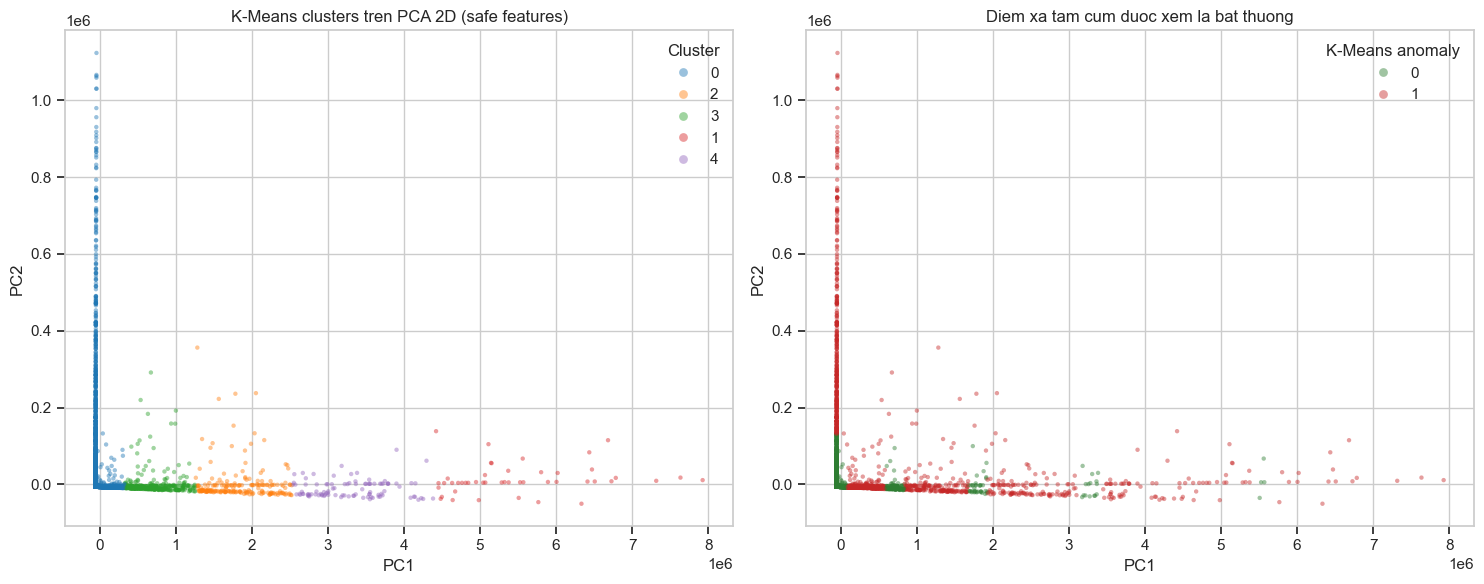

In [19]:
if PLOT_SAMPLE_ROWS is not None and len(X_safe_scaled) > PLOT_SAMPLE_ROWS:
    plot_indices, _ = train_test_split(
        np.arange(len(X_safe_scaled)),
        train_size=PLOT_SAMPLE_ROWS,
        random_state=RANDOM_STATE,
        stratify=y,
    )
else:
    plot_indices = np.arange(len(X_safe_scaled))

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_plot_pca = pca.fit_transform(X_safe_scaled[plot_indices])
plot_frame = pd.DataFrame({
    'PC1': X_plot_pca[:, 0],
    'PC2': X_plot_pca[:, 1],
    'cluster': anomalies['kmeans_cluster'].iloc[plot_indices].astype(str).values,
    'kmeans_anomaly': anomalies['kmeans_pred'].iloc[plot_indices].values,
    'rule_anomaly': y.iloc[plot_indices].values,
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(
    data=plot_frame,
    x='PC1', y='PC2', hue='cluster',
    s=10, alpha=0.45, linewidth=0, palette='tab10', ax=axes[0],
)
axes[0].set_title('K-Means clusters tren PCA 2D (safe features)')
axes[0].legend(title='Cluster', markerscale=2)

sns.scatterplot(
    data=plot_frame,
    x='PC1', y='PC2', hue='kmeans_anomaly',
    s=10, alpha=0.45, linewidth=0, palette={0: COLORS['normal'], 1: COLORS['anomaly']}, ax=axes[1],
)
axes[1].set_title('Diem xa tam cum duoc xem la bat thuong')
axes[1].legend(title='K-Means anomaly', markerscale=2)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_kmeans_pca.png', dpi=160, bbox_inches='tight')
plt.show()

## 12. Người 5 - Isolation Forest

Isolation Forest là thuật toán phát hiện bất thường không giám sát. Mô hình không dùng nhãn luật khi huấn luyện; phần metric chỉ là overlap với pseudo-label.


Isolation Forest - safe_features - Unsupervised overlap with pseudo-label
              precision    recall  f1-score   support

      Normal       0.99      0.96      0.97   1374159
     Anomaly       0.21      0.44      0.28     33421

    accuracy                           0.95   1407580
   macro avg       0.60      0.70      0.63   1407580
weighted avg       0.97      0.95      0.96   1407580



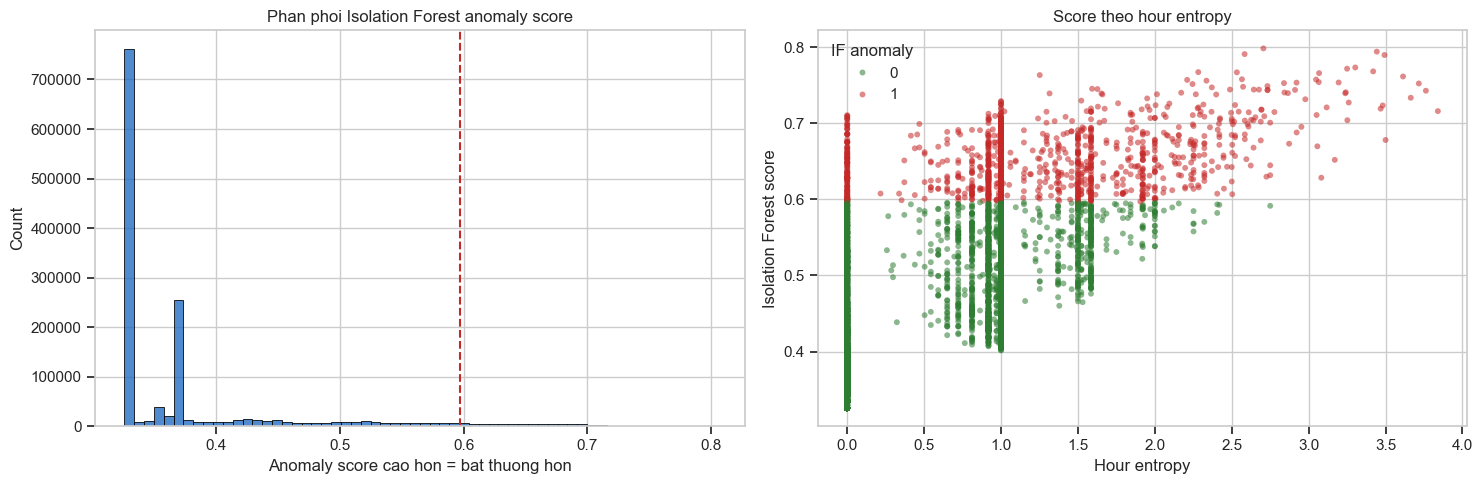

In [20]:
if IFOREST_TRAIN_ROWS is not None and len(X_safe_scaled) > IFOREST_TRAIN_ROWS:
    rng = np.random.default_rng(RANDOM_STATE)
    iforest_train_indices = rng.choice(len(X_safe_scaled), size=IFOREST_TRAIN_ROWS, replace=False)
else:
    iforest_train_indices = np.arange(len(X_safe_scaled))

iforest_model = IsolationForest(
    n_estimators=150,
    contamination=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iforest_model.fit(X_safe_scaled[iforest_train_indices])

iforest_raw_pred = iforest_model.predict(X_safe_scaled)
iforest_score = -iforest_model.score_samples(X_safe_scaled)
iforest_pred = (iforest_raw_pred == -1).astype(int)

anomalies['isolation_forest_score'] = iforest_score
anomalies['isolation_forest_pred'] = iforest_pred
main_model_predictions['isolation_forest_pred'] = anomalies['isolation_forest_pred']

add_evaluation('Isolation Forest', 'safe_features', 'Unsupervised overlap with pseudo-label', y, iforest_pred, iforest_score)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(anomalies['isolation_forest_score'], bins=60, color=COLORS['primary'], ax=axes[0])
axes[0].axvline(anomalies.loc[anomalies['isolation_forest_pred'] == 1, 'isolation_forest_score'].min(), color=COLORS['anomaly'], linestyle='--')
axes[0].set_title('Phan phoi Isolation Forest anomaly score')
axes[0].set_xlabel('Anomaly score cao hon = bat thuong hon')

score_sample = anomalies.sample(min(PLOT_SAMPLE_ROWS, len(anomalies)), random_state=RANDOM_STATE)
sns.scatterplot(
    data=score_sample,
    x='hour_entropy', y='isolation_forest_score', hue='isolation_forest_pred',
    palette={0: COLORS['normal'], 1: COLORS['anomaly']}, alpha=0.55, linewidth=0, s=18, ax=axes[1],
)
axes[1].set_title('Score theo hour entropy')
axes[1].set_xlabel('Hour entropy')
axes[1].set_ylabel('Isolation Forest score')
axes[1].legend(title='IF anomaly')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_isolation_scores.png', dpi=160, bbox_inches='tight')
plt.show()

## 13. So sánh 5 thuật toán

Bảng chính dùng `safe_features`. Với supervised models, metric là mức độ khớp với pseudo-label từ luật nghiệp vụ sau khi giảm leakage. Với unsupervised models, metric là overlap tham khảo với pseudo-label, không phải chất lượng phát hiện thật.

Bang metric chinh tren safe features / pseudo-label overlap:


,model,feature_set,evaluation_type,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
0,Dummy baseline,safe_features,Baseline vs pseudo-label,0.9538,0.0172,0.0168,0.0170,0.4967,0.0236,1187,1162
1,XGBoost,safe_features,Main supervised vs pseudo-label,0.9628,0.3891,0.9933,0.5592,0.9939,0.7915,1187,3030
2,Decision Tree,safe_features,Main supervised vs pseudo-label,0.9369,0.2726,0.9949,0.4280,0.9876,0.6004,1187,4332
3,Random Forest,safe_features,Main supervised vs pseudo-label,0.9519,0.3299,0.9949,0.4955,0.9921,0.7280,1187,3580
8,K-Means,safe_features,Unsupervised overlap with pseudo-label,0.9392,0.1292,0.2722,0.1753,0.5492,0.0731,33421,70379
9,Isolation Forest,safe_features,Unsupervised overlap with pseudo-label,0.9473,0.2096,0.4398,0.2839,0.9295,0.2240,33421,70114


Bang phu: full features hoc lai luat nghiep vu:


,model,feature_set,evaluation_type,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
4,XGBoost,full_features,Rule-mimic / agreement with business rules,0.9993,0.9705,0.9992,0.9846,1.0000,0.9999,1187,1222
5,Decision Tree,full_features,Rule-mimic / agreement with business rules,0.9949,0.8257,0.9975,0.9035,0.9999,0.9945,1187,1434
6,Random Forest,full_features,Rule-mimic / agreement with business rules,0.9941,0.8019,0.9992,0.8897,0.9999,0.9962,1187,1479


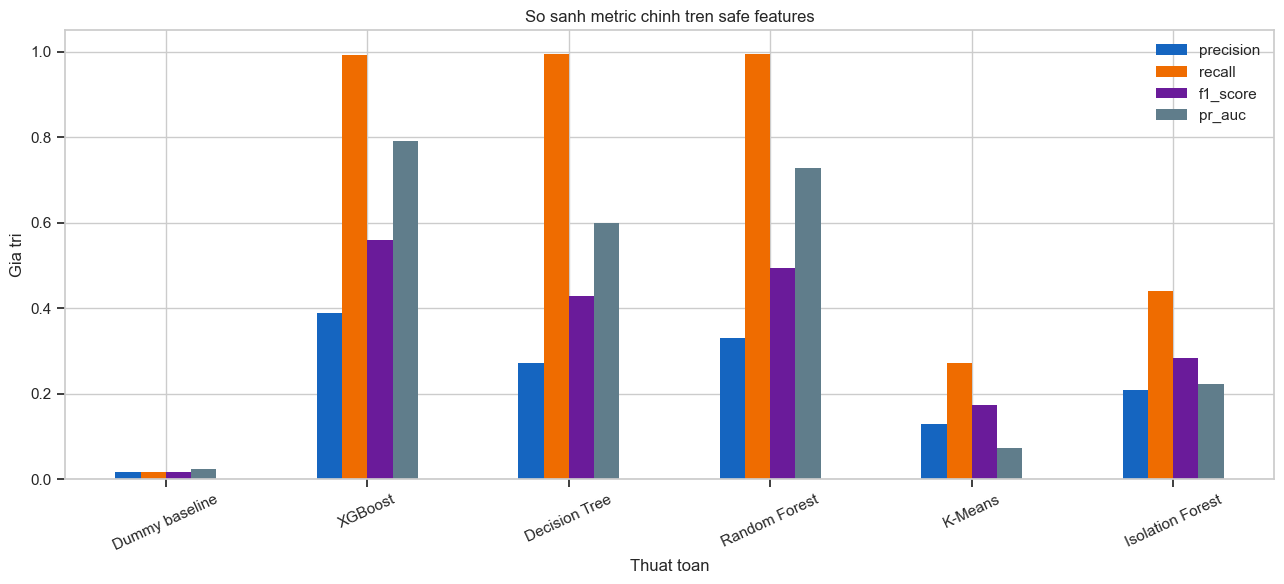

In [21]:
metrics_df = pd.DataFrame(evaluation_records)
metric_cols = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc']
metrics_df[metric_cols] = metrics_df[metric_cols].round(4)

main_metrics_df = metrics_df[
    metrics_df['evaluation_type'].isin([
        'Baseline vs pseudo-label',
        'Main supervised vs pseudo-label',
        'Unsupervised overlap with pseudo-label',
    ])
].copy()

rule_mimic_metrics_df = metrics_df[
    metrics_df['evaluation_type'] == 'Rule-mimic / agreement with business rules'
].copy()

print('Bang metric chinh tren safe features / pseudo-label overlap:')
display(main_metrics_df)
print('Bang phu: full features hoc lai luat nghiep vu:')
display(rule_mimic_metrics_df)

fig, ax = plt.subplots(figsize=(13, 6))
plot_metrics = main_metrics_df.set_index('model')[['precision', 'recall', 'f1_score', 'pr_auc']]
plot_metrics.plot(kind='bar', ax=ax, color=[COLORS['primary'], COLORS['warning'], COLORS['secondary'], COLORS['muted']])
ax.set_title('So sanh metric chinh tren safe features')
ax.set_xlabel('Thuat toan')
ax.set_ylabel('Gia tri')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=25)
ax.legend(loc='upper right')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_model_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

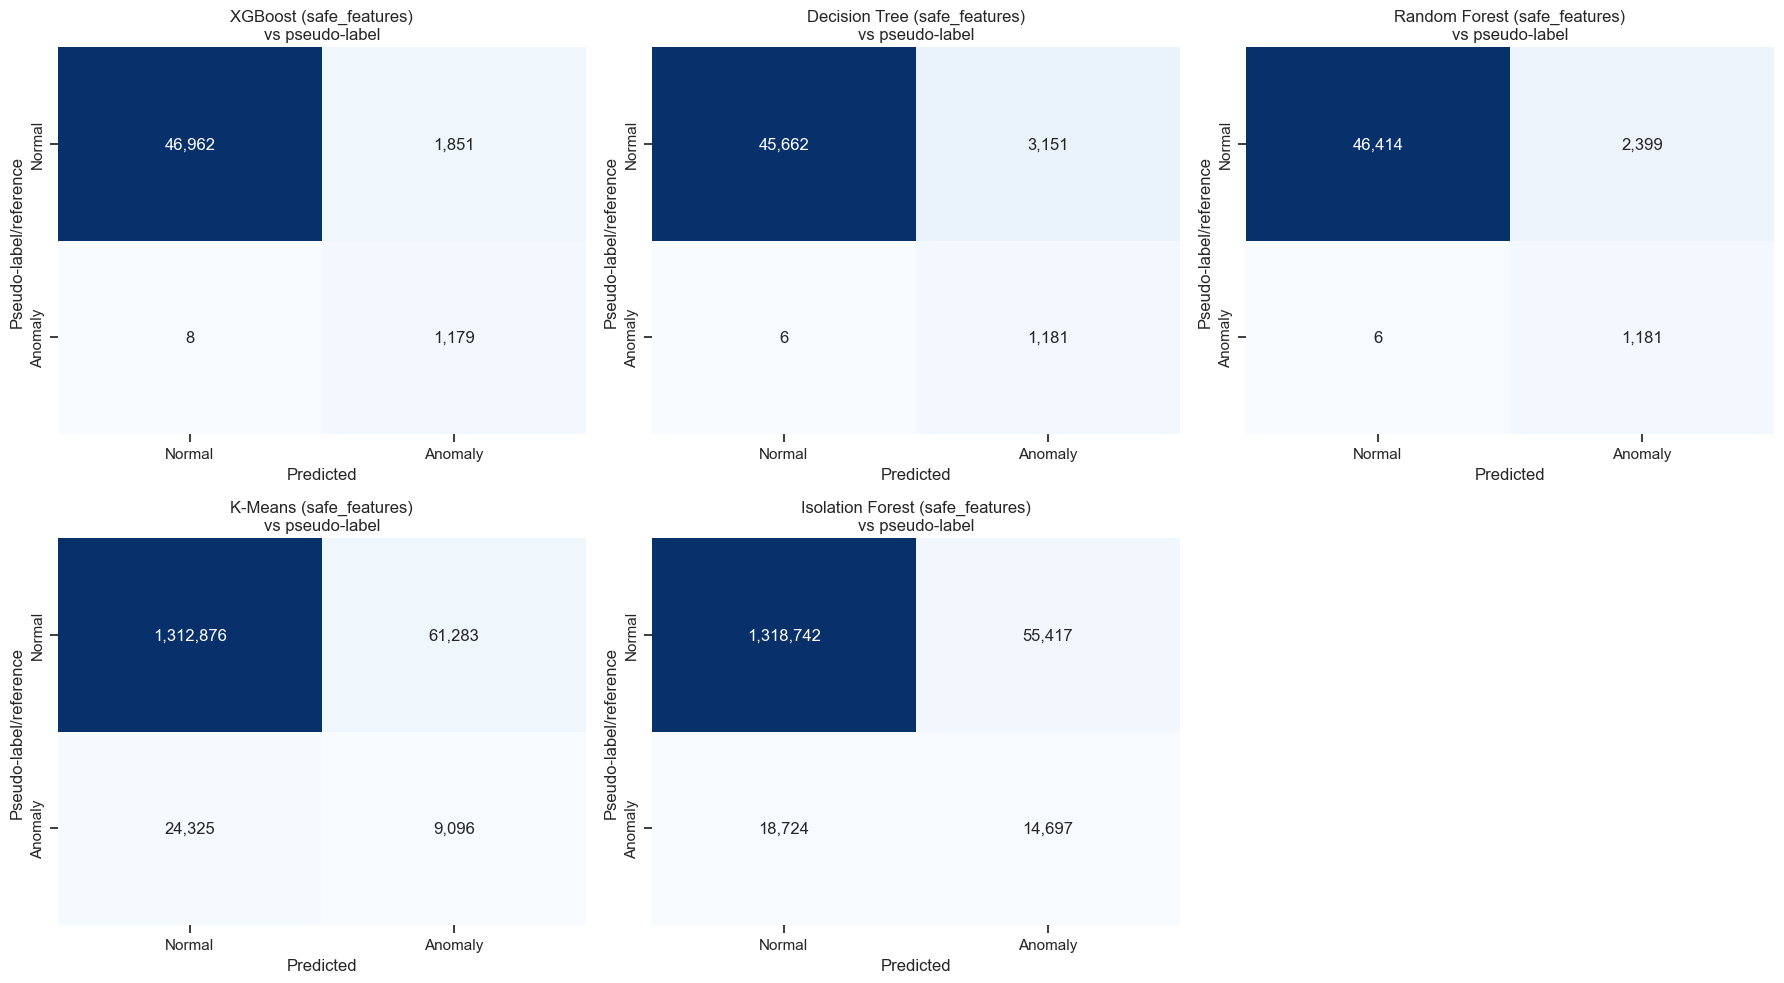

In [22]:
confusion_items = {
    key: value
    for key, value in prediction_sets.items()
    if key in [
        'XGBoost (safe_features)',
        'Decision Tree (safe_features)',
        'Random Forest (safe_features)',
        'K-Means (safe_features)',
        'Isolation Forest (safe_features)',
    ]
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, (model_name, values) in zip(axes, confusion_items.items()):
    cm = confusion_matrix(values['y_true'], values['y_pred'], labels=[0, 1])
    sns.heatmap(
        cm,
        annot=True,
        fmt=',d',
        cmap='Blues',
        xticklabels=['Normal', 'Anomaly'],
        yticklabels=['Normal', 'Anomaly'],
        cbar=False,
        ax=ax,
    )
    ax.set_title(f'{model_name}\nvs pseudo-label')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Pseudo-label/reference')

for ax in axes[len(confusion_items):]:
    ax.axis('off')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_confusion_matrices.png', dpi=160, bbox_inches='tight')
plt.show()

## 14. Báo cáo bất thường và export

Bảng report tổng hợp visitor bị đánh dấu bởi luật nghiệp vụ hoặc bởi ít nhất một mô hình chính trên safe feature set. Cột `model_vote_count` cho biết số thuật toán chính đánh dấu visitor là bất thường.

In [23]:
model_pred_cols = [
    'xgboost_pred',
    'decision_tree_pred',
    'random_forest_pred',
    'kmeans_pred',
    'isolation_forest_pred',
]
anomalies['model_vote_count'] = anomalies[model_pred_cols].sum(axis=1)
anomalies['is_anomaly_final'] = ((anomalies['is_anomaly_rule'] == 1) | (anomalies['model_vote_count'] > 0)).astype(int)

score_99 = anomalies['isolation_forest_score'].quantile(0.99)

def classify_severity(row):
    if row['total_flags'] >= 3 or row['model_vote_count'] >= 4 or row['isolation_forest_score'] >= score_99:
        return 'CRITICAL'
    if row['total_flags'] >= 2 or row['model_vote_count'] >= 2:
        return 'HIGH'
    if row['total_flags'] == 1 or row['model_vote_count'] == 1:
        return 'MEDIUM'
    return 'LOW'

anomalies['severity'] = anomalies.apply(classify_severity, axis=1)
severity_order = {'CRITICAL': 3, 'HIGH': 2, 'MEDIUM': 1, 'LOW': 0}
anomalies['severity_rank'] = anomalies['severity'].map(severity_order)

if not (anomalies['anomaly_type_count'] == anomalies['total_flags']).all():
    raise ValueError('anomaly_type_count phai bang total_flags truoc khi export')
if not (anomalies.loc[anomalies['is_anomaly'] == 0, 'anomaly_types'] == 'Normal').all():
    raise ValueError('Normal visitor phai co anomaly_types = Normal truoc khi export')

report_cols = [
    'is_anomaly', 'anomaly_types', 'anomaly_type_count',
    'unique_items', 'active_hours', 'unique_event_types', 'event_type_entropy', 'hour_entropy',
    'peak_events', 'weekend_events', 'peak_ratio', 'weekend_ratio',
    'total_flags', 'is_anomaly_rule',
    'xgboost_score', 'decision_tree_score', 'random_forest_score',
    'kmeans_distance', 'isolation_forest_score',
] + model_pred_cols + ['model_vote_count', 'severity'] + flag_cols

anomaly_report = (
    anomalies[anomalies['is_anomaly_final'] == 1]
    .sort_values(
        ['severity_rank', 'model_vote_count', 'total_flags', 'isolation_forest_score'],
        ascending=[False, False, False, False],
    )[report_cols]
    .reset_index()
)

visitor_anomaly_tags = anomalies[
    ['is_anomaly', 'anomaly_types', 'anomaly_type_count', 'total_flags'] + flag_cols
].reset_index()

tag_example_cols = ['visitorid', 'is_anomaly', 'anomaly_types', 'total_flags', 'model_vote_count', 'severity']
tag_examples = anomaly_report[tag_example_cols].head(15)

anomaly_report.to_csv(OUTPUT_DIR / 'group_anomaly_report.csv', index=False)
visitor_anomaly_tags.to_csv(OUTPUT_DIR / 'visitor_anomaly_tags.csv', index=False)
metrics_df.to_csv(OUTPUT_DIR / 'group_model_metrics.csv', index=False)
leakage_audit_df.to_csv(OUTPUT_DIR / 'group_leakage_audit.csv', index=False)
anomaly_type_breakdown.to_csv(OUTPUT_DIR / 'group_anomaly_type_breakdown.csv', index=False)

print(f'So visitor trong anomaly report: {len(anomaly_report):,}')
print('Da export: group_anomaly_report.csv')
print('Da export: visitor_anomaly_tags.csv')
print('Da export: group_model_metrics.csv')
print('Da export: group_leakage_audit.csv')
print('Da export: group_anomaly_type_breakdown.csv')
print('\nVi du bang multi-label tagging:')
display(tag_examples)

So visitor trong anomaly report: 173,752
Da export: group_anomaly_report.csv
Da export: visitor_anomaly_tags.csv
Da export: group_model_metrics.csv
Da export: group_leakage_audit.csv
Da export: group_anomaly_type_breakdown.csv

Vi du bang multi-label tagging:


,visitorid,is_anomaly,anomaly_types,total_flags,model_vote_count,severity
0,1015928,1,"Bot scraper, Night crawler, Item hoarding, Ses...",4,5,CRITICAL
1,1076366,1,"Rapid-fire, Night crawler, Item hoarding, Sequ...",4,5,CRITICAL
2,48820,1,"Bot scraper, Rapid-fire, Night crawler, Item h...",4,5,CRITICAL
3,891328,1,"Ghost buyer, Rapid-fire, Night crawler, Sequen...",4,5,CRITICAL
4,918277,1,"Ghost buyer, Rapid-fire, Sequence violation",3,5,CRITICAL
5,1083118,1,"Night crawler, Item hoarding, Sequence violation",3,5,CRITICAL
6,550158,1,"Rapid-fire, Night crawler, Item hoarding",3,5,CRITICAL
7,566009,1,"Rapid-fire, Session bomb, Sequence violation",3,5,CRITICAL
8,288932,1,"Rapid-fire, Night crawler, Item hoarding",3,5,CRITICAL
9,686854,1,"Bot scraper, Rapid-fire, Item hoarding",3,5,CRITICAL


## 15. Kết luận báo cáo

- Notebook đã chuyển phần giải thích luật nghiệp vụ sang multi-label anomaly tagging ở cấp `visitorid`.
- Mỗi visitor có `is_anomaly`, `anomaly_types`, `anomaly_type_count`; visitor bình thường có `anomaly_types = Normal`.
- Rule mới `Sequence violation` được tính từ timeline raw events theo từng cặp `visitorid` + `itemid`.
- Metric ban đầu quá đẹp vì full feature set chứa các feature trực tiếp tạo ra `is_anomaly_rule`.
- Bảng chính dùng safe feature set để giảm label leakage, nên kết quả phản ánh trung thực hơn mức độ khớp với pseudo-label.
- K-Means và Isolation Forest không dùng nhãn khi train; metric của hai thuật toán này là overlap với luật nghiệp vụ.
- RetailRocket không có nhãn anomaly thật, vì vậy mọi đánh giá định lượng và multi-label tag trong notebook là theo pseudo-label do nhóm thiết kế.

In [24]:
print('=' * 70)
print('TONG KET DO AN NHOM')
print('=' * 70)
print(f'Dataset: RetailRocket E-commerce events')
print(f'So event: {len(events):,}')
print(f'So visitor profile: {len(anomalies):,}')
print(f'Bat thuong theo business rules: {anomalies["is_anomaly_rule"].sum():,} ({anomalies["is_anomaly_rule"].mean() * 100:.2f}%)')
print(f'Bat thuong theo ket qua tong hop: {anomalies["is_anomaly_final"].sum():,} ({anomalies["is_anomaly_final"].mean() * 100:.2f}%)')
print('\nBang metric chinh:')
display(main_metrics_df)
print('\nBang phu full features hoc lai luat:')
display(rule_mimic_metrics_df)
print('\nBreakdown anomaly type:')
display(anomaly_type_breakdown)
print('\nVi du multi-label anomaly tagging:')
display(visitor_anomaly_tags[visitor_anomaly_tags['is_anomaly'] == 1].head(10))
print('\nPhan bo muc do nghiem trong:')
display(anomalies[anomalies['is_anomaly_final'] == 1]['severity'].value_counts().rename_axis('severity').reset_index(name='count'))

TONG KET DO AN NHOM
Dataset: RetailRocket E-commerce events
So event: 2,756,101
So visitor profile: 1,407,580
Bat thuong theo business rules: 33,421 (2.37%)
Bat thuong theo ket qua tong hop: 173,752 (12.34%)

Bang metric chinh:


,model,feature_set,evaluation_type,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
0,Dummy baseline,safe_features,Baseline vs pseudo-label,0.9538,0.0172,0.0168,0.0170,0.4967,0.0236,1187,1162
1,XGBoost,safe_features,Main supervised vs pseudo-label,0.9628,0.3891,0.9933,0.5592,0.9939,0.7915,1187,3030
2,Decision Tree,safe_features,Main supervised vs pseudo-label,0.9369,0.2726,0.9949,0.4280,0.9876,0.6004,1187,4332
3,Random Forest,safe_features,Main supervised vs pseudo-label,0.9519,0.3299,0.9949,0.4955,0.9921,0.7280,1187,3580
8,K-Means,safe_features,Unsupervised overlap with pseudo-label,0.9392,0.1292,0.2722,0.1753,0.5492,0.0731,33421,70379
9,Isolation Forest,safe_features,Unsupervised overlap with pseudo-label,0.9473,0.2096,0.4398,0.2839,0.9295,0.2240,33421,70114



Bang phu full features hoc lai luat:


,model,feature_set,evaluation_type,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
4,XGBoost,full_features,Rule-mimic / agreement with business rules,0.9993,0.9705,0.9992,0.9846,1.0000,0.9999,1187,1222
5,Decision Tree,full_features,Rule-mimic / agreement with business rules,0.9949,0.8257,0.9975,0.9035,0.9999,0.9945,1187,1434
6,Random Forest,full_features,Rule-mimic / agreement with business rules,0.9941,0.8019,0.9992,0.8897,0.9999,0.9962,1187,1479



Breakdown anomaly type:


,anomaly_type,count,percent_visitors
4,Night crawler,24265,1.723881
2,Click fraud,6452,0.458375
3,Rapid-fire,3711,0.263644
0,Bot scraper,1275,0.090581
1,Ghost buyer,1143,0.081203
5,Item hoarding,735,0.052217
7,Sequence violation,444,0.031544
6,Session bomb,188,0.013356



Vi du multi-label anomaly tagging:


,visitorid,is_anomaly,anomaly_types,anomaly_type_count,total_flags,flag_BR01_bot_scraper,flag_BR02_ghost_buyer,flag_BR03_click_fraud,flag_BR04_rapid_fire,flag_BR05_night_crawler,flag_BR06_item_hoarding,flag_BR07_session_bomb,flag_BR08_sequence_violation
75,75,1,Click fraud,1,1,0,0,1,0,0,0,0,0
97,97,1,Night crawler,1,1,0,0,0,0,1,0,0,0
162,162,1,Night crawler,1,1,0,0,0,0,1,0,0,0
172,172,1,Night crawler,1,1,0,0,0,0,1,0,0,0
224,224,1,Night crawler,1,1,0,0,0,0,1,0,0,0
264,264,1,Rapid-fire,1,1,0,0,0,1,0,0,0,0
344,344,1,Night crawler,1,1,0,0,0,0,1,0,0,0
351,351,1,Click fraud,1,1,0,0,1,0,0,0,0,0
374,374,1,Night crawler,1,1,0,0,0,0,1,0,0,0
387,387,1,Night crawler,1,1,0,0,0,0,1,0,0,0



Phan bo muc do nghiem trong:


,severity,count
0,HIGH,98631
1,CRITICAL,40159
2,MEDIUM,34962
